# Hotel Bar Inventory Forecasting and Par Level Recommendation
This notebook turns transaction-level bar inventory records into daily demand series, compares a seasonal baseline with a Random Forest forecast, calculates dynamic par levels, and backtests an order-up-to policy.

The analysis is chronological: the first 80% of dates is training data and the final 20% is validation data.

In [11]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data' / 'processed'
FIGURE_DIR = ROOT / 'report' / 'figures'
REPORT_DIR = ROOT / 'report'
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_XLSX = ROOT / 'Consumption Dataset.xlsx'
print(f'Project root: {ROOT}')
print(f'Original dataset: {SOURCE_XLSX}')
print(f'Input exists: {SOURCE_XLSX.exists()}')
if not SOURCE_XLSX.exists():
    raise FileNotFoundError(f'Missing original dataset: {SOURCE_XLSX}')

Project root: d:\Nxtwave Projects\ML - Inventory Demand Forecasting and Par Level Recommendation System for Bars
Original dataset: d:\Nxtwave Projects\ML - Inventory Demand Forecasting and Par Level Recommendation System for Bars\Consumption Dataset.xlsx
Input exists: True


## Project paths and generated files


In [ ]:
OUTPUT_PATHS = {
    'Original transaction dataset': SOURCE_XLSX,
    'Clean daily CSV': DATA_DIR / 'daily_bar_consumption.csv',
    'Alcohol category CSV': DATA_DIR / 'category_consumption.csv',
    'Forecast metrics CSV': DATA_DIR / 'forecast_metrics.csv',
    'Par-level recommendations CSV': DATA_DIR / 'par_level_recommendations.csv',
    'ABC segmentation CSV': DATA_DIR / 'abc_inventory_segmentation.csv',
    'Deployment recommendations CSV': ROOT / 'outputs' / 'inventory_recommendations.csv',
    'Serialized forecasting model': ROOT / 'models' / 'forecasting_model.pkl',
    'EDA figure': FIGURE_DIR / 'eda_overview.png',
    'Category figure': FIGURE_DIR / 'category_consumption.png',
    'Model comparison figure': FIGURE_DIR / 'forecast_model_comparison.png',
    'Inventory policy figure': FIGURE_DIR / 'inventory_policy_example.png',
    'Markdown report': REPORT_DIR / 'business_report.md',
    'PDF report': REPORT_DIR / 'business_report.pdf',
    'Streamlit dashboard': ROOT / 'app.py',
}

print('Absolute project paths:')
for label, path in OUTPUT_PATHS.items():
    exists = path.exists()
    print(f'- {label}: {path} | exists={exists}')

print('\nLaunch the dashboard from the project root with:')
print(f'  python -m streamlit run "{OUTPUT_PATHS["Streamlit dashboard"]}"')

Absolute project paths:
- Original transaction dataset: d:\Nxtwave Projects\ML - Inventory Demand Forecasting and Par Level Recommendation System for Bars\Consumption Dataset.xlsx | exists=True
- Clean daily CSV: d:\Nxtwave Projects\ML - Inventory Demand Forecasting and Par Level Recommendation System for Bars\data\processed\daily_bar_consumption.csv | exists=True
- Forecast metrics CSV: d:\Nxtwave Projects\ML - Inventory Demand Forecasting and Par Level Recommendation System for Bars\data\processed\forecast_metrics.csv | exists=True
- Par-level recommendations CSV: d:\Nxtwave Projects\ML - Inventory Demand Forecasting and Par Level Recommendation System for Bars\data\processed\par_level_recommendations.csv | exists=True
- ABC segmentation CSV: d:\Nxtwave Projects\ML - Inventory Demand Forecasting and Par Level Recommendation System for Bars\data\processed\abc_inventory_segmentation.csv | exists=True
- EDA figure: d:\Nxtwave Projects\ML - Inventory Demand Forecasting and Par Level Reco

## 1. Load, clean, and aggregate the original transaction data

In [12]:
raw = pd.read_excel(SOURCE_XLSX, sheet_name='Dataset')
required = {
    'Date Time Served', 'Bar Name', 'Brand Name', 'Opening Balance (ml)',
    'Purchase (ml)', 'Consumed (ml)', 'Closing Balance (ml)',
}
missing = sorted(required - set(raw.columns))
if missing:
    raise ValueError(f'Missing required columns: {missing}')

raw['Date Time Served'] = pd.to_datetime(raw['Date Time Served'], errors='coerce')
numeric_columns = ['Opening Balance (ml)', 'Purchase (ml)', 'Consumed (ml)', 'Closing Balance (ml)']
raw[numeric_columns] = raw[numeric_columns].apply(pd.to_numeric, errors='coerce')
quality = {
    'rows_loaded': len(raw),
    'invalid_dates': int(raw['Date Time Served'].isna().sum()),
    'invalid_numeric_values': int(raw[numeric_columns].isna().any(axis=1).sum()),
    'duplicate_rows': int(raw.duplicated().sum()),
    'negative_consumption': int((raw['Consumed (ml)'] < 0).sum()),
}
if quality['invalid_dates'] or quality['invalid_numeric_values']:
    raise ValueError(f'Invalid date or numeric values: {quality}')
if quality['negative_consumption']:
    raise ValueError(f'Negative consumption values found: {quality}')

raw['conservation_error_ml'] = (
    raw['Opening Balance (ml)'] + raw['Purchase (ml)']
    - raw['Consumed (ml)'] - raw['Closing Balance (ml)']
)
print(f"Rows loaded: {quality['rows_loaded']:,}")
print(f"Bars: {raw['Bar Name'].nunique()} | Brands: {raw['Brand Name'].nunique()}")
print(f"Date range: {raw['Date Time Served'].min().date()} to {raw['Date Time Served'].max().date()}")
print(f"Maximum absolute conservation error (ml): {raw['conservation_error_ml'].abs().max():.8f}")
print(f'Quality checks: {quality}')
raw.head()

Rows loaded: 6,575
Bars: 6 | Brands: 16
Date range: 2023-01-01 to 2024-01-01
Maximum absolute conservation error (ml): 0.00000000
Quality checks: {'rows_loaded': 6575, 'invalid_dates': 0, 'invalid_numeric_values': 0, 'duplicate_rows': 0, 'negative_consumption': 0}


,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),conservation_error_ml
0,2023-01-01 19:35:00,Smith's Bar,Rum,Captain Morgan,2555.04,1824.84,0.0,4379.88,0.0
1,2023-01-01 10:07:00,Smith's Bar,Wine,Yellow Tail,1344.37,0.00,0.0,1344.37,0.0
2,2023-01-01 11:26:00,Johnson's Bar,Vodka,Grey Goose,1034.28,0.00,0.0,1034.28,0.0
3,2023-01-01 13:53:00,Johnson's Bar,Beer,Coors,2194.53,0.00,0.0,2194.53,0.0
4,2023-01-01 22:28:00,Johnson's Bar,Wine,Yellow Tail,1020.90,0.00,0.0,1020.90,0.0


In [13]:
raw['Date'] = raw['Date Time Served'].dt.floor('D')
daily = (raw.groupby(['Date', 'Bar Name', 'Brand Name'], as_index=False)['Consumed (ml)']
         .sum())
pairs = daily[['Bar Name', 'Brand Name']].drop_duplicates()
dates = pd.date_range(daily['Date'].min(), daily['Date'].max(), freq='D')
grid = (pairs.assign(_key=1)
        .merge(pd.DataFrame({'Date': dates, '_key': 1}), on='_key')
        .drop(columns='_key'))
daily_ts = (grid.merge(daily, on=['Date', 'Bar Name', 'Brand Name'], how='left')
            .fillna({'Consumed (ml)': 0.0})
            .sort_values(['Bar Name', 'Brand Name', 'Date'])
            .reset_index(drop=True))
daily_ts.to_csv(DATA_DIR / 'daily_bar_consumption.csv', index=False)
print(f'Complete daily rows: {len(daily_ts):,}')
print(f'Observed bar-brand pairs: {len(pairs):,}')
print(f'Zero-demand rows after completion: {daily_ts["Consumed (ml)"].eq(0).mean():.1%}')
daily_ts.head()

Complete daily rows: 35,136
Observed bar-brand pairs: 96
Zero-demand rows after completion: 83.9%


,Bar Name,Brand Name,Date,Consumed (ml)
0,Anderson's Bar,Absolut,2023-01-01,0.00
1,Anderson's Bar,Absolut,2023-01-02,118.62
2,Anderson's Bar,Absolut,2023-01-03,0.00
3,Anderson's Bar,Absolut,2023-01-04,0.00
4,Anderson's Bar,Absolut,2023-01-05,463.20


## 2. Exploratory analysis and demand segmentation

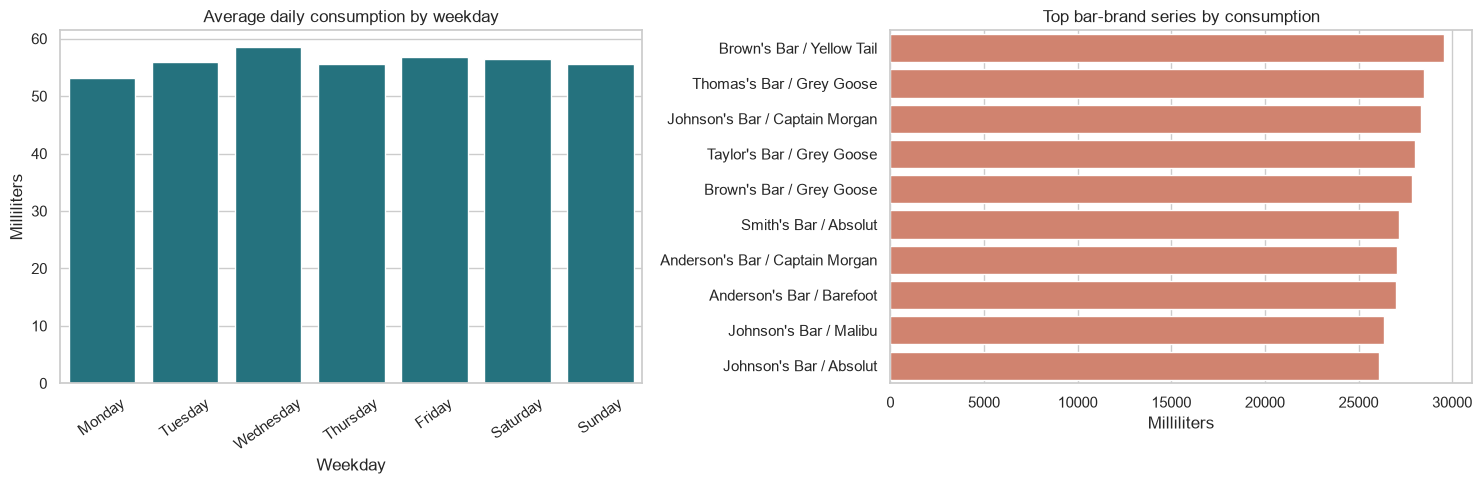

In [14]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
eda = daily_ts.copy()
eda['Weekday'] = eda['Date'].dt.day_name()
weekday = eda.groupby('Weekday')['Consumed (ml)'].mean().reindex(weekday_order)
top_series = (eda.groupby(['Bar Name', 'Brand Name'])['Consumed (ml)'].sum()
              .sort_values(ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=weekday.index, y=weekday.values, color='#167d8d', ax=axes[0])
axes[0].set_title('Average daily consumption by weekday')
axes[0].set_ylabel('Milliliters')
axes[0].tick_params(axis='x', rotation=35)
sns.barplot(x=top_series.values, y=[f'{bar} / {brand}' for bar, brand in top_series.index], color='#e07a5f', ax=axes[1])
axes[1].set_title('Top bar-brand series by consumption')
axes[1].set_xlabel('Milliliters')
axes[1].set_ylabel('')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'eda_overview.png', dpi=160, bbox_inches='tight')
plt.show()

## 2.1 Alcohol-category consumption analysis


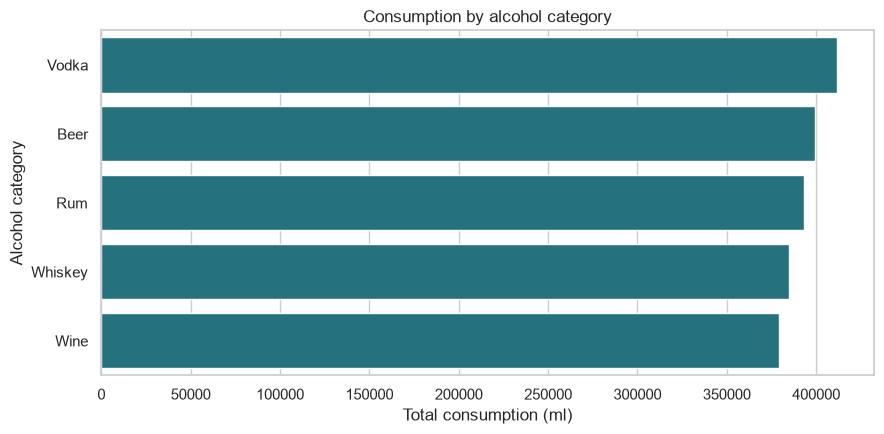

,Alcohol Type,total_consumption_ml,average_transaction_ml,transactions,consumption_share
0,Vodka,411759.71,309.361165,1331,0.209155
1,Beer,399498.39,306.834401,1302,0.202927
2,Rum,393266.84,300.203695,1310,0.199762
3,Whiskey,384754.46,292.366611,1316,0.195438
4,Wine,379402.26,288.299590,1316,0.192719


In [22]:
category_consumption = (raw.groupby('Alcohol Type')['Consumed (ml)']
                       .agg(total_consumption_ml='sum', average_transaction_ml='mean', transactions='size')
                       .sort_values('total_consumption_ml', ascending=False)
                       .reset_index())
category_consumption['consumption_share'] = (
    category_consumption['total_consumption_ml'] / category_consumption['total_consumption_ml'].sum()
)
category_consumption.to_csv(DATA_DIR / 'category_consumption.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=category_consumption,
    x='total_consumption_ml',
    y='Alcohol Type',
    color='#167d8d',
    ax=ax,
)
ax.set_title('Consumption by alcohol category')
ax.set_xlabel('Total consumption (ml)')
ax.set_ylabel('Alcohol category')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'category_consumption.png', dpi=160, bbox_inches='tight')
plt.show()
category_consumption

In [15]:
annual = (daily_ts.groupby(['Bar Name', 'Brand Name'])['Consumed (ml)']
          .sum().sort_values(ascending=False))
abc_table = annual.rename('annual_consumption_ml').to_frame()
abc_table['cumulative_share'] = abc_table['annual_consumption_ml'].cumsum() / annual.sum()
abc_table['ABC_class'] = pd.cut(
    abc_table['cumulative_share'], bins=[0, 0.80, 0.95, 1.0],
    labels=['A', 'B', 'C'], include_lowest=True,
)
abc_table = abc_table.reset_index()
abc_table.to_csv(DATA_DIR / 'abc_inventory_segmentation.csv', index=False)
abc_table.head(10)

,Bar Name,Brand Name,annual_consumption_ml,cumulative_share,ABC_class
0,Brown's Bar,Yellow Tail,29588.63,0.015030,A
1,Thomas's Bar,Grey Goose,28510.30,0.029512,A
2,Johnson's Bar,Captain Morgan,28319.66,0.043897,A
3,Taylor's Bar,Grey Goose,28017.89,0.058128,A
4,Brown's Bar,Grey Goose,27873.30,0.072287,A
5,Smith's Bar,Absolut,27181.45,0.086094,A
6,Anderson's Bar,Captain Morgan,27066.83,0.099842,A
7,Anderson's Bar,Barefoot,26989.63,0.113552,A
8,Johnson's Bar,Malibu,26356.51,0.126940,A
9,Johnson's Bar,Absolut,26070.31,0.140182,A


## 3. Chronological forecasting and evaluation

In [25]:
model_df = daily_ts.copy()
grouped = model_df.groupby(['Bar Name', 'Brand Name'], sort=False)['Consumed (ml)']
for lag in [1, 7, 14]:
    model_df[f'lag_{lag}'] = grouped.shift(lag)
shifted = grouped.shift(1)
model_df['rolling_mean_7'] = shifted.transform(lambda values: values.rolling(7, min_periods=3).mean())
model_df['rolling_std_7'] = shifted.transform(lambda values: values.rolling(7, min_periods=3).std())
model_df['dayofweek'] = model_df['Date'].dt.dayofweek
model_df['is_weekend'] = model_df['dayofweek'].isin([5, 6]).astype(int)
model_df = model_df.dropna(subset=['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7']).copy()

feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'dayofweek', 'is_weekend', 'Bar Name', 'Brand Name']
categorical = ['Bar Name', 'Brand Name']
cutoff = model_df['Date'].min() + (model_df['Date'].max() - model_df['Date'].min()) * 0.8
train = model_df[model_df['Date'] < cutoff].copy()
test = model_df[model_df['Date'] >= cutoff].copy()

preprocess = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical),
], remainder='passthrough')
rf = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(n_estimators=60, min_samples_leaf=3, random_state=42, n_jobs=-1)),
])
rf.fit(train[feature_cols], train['Consumed (ml)'])
test['moving_average_7'] = test['rolling_mean_7'].clip(lower=0)
test['seasonal_naive_7'] = test['lag_7'].clip(lower=0)
test['random_forest'] = np.maximum(0, rf.predict(test[feature_cols]))
print(f'Train rows: {len(train):,} | Validation rows: {len(test):,} | Cutoff: {cutoff.date()}')

Train rows: 26,976 | Validation rows: 6,816 | Cutoff: 2023-10-22


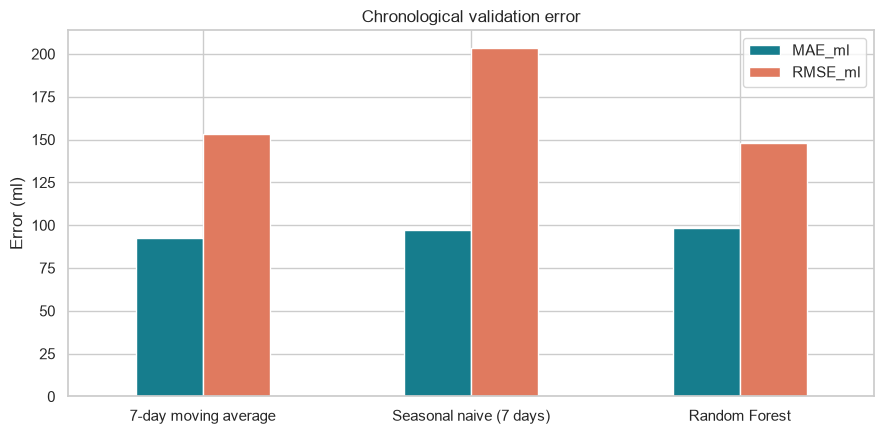

,MAE_ml,RMSE_ml,WAPE
7-day moving average,92.6,153.2,166.3%
Seasonal naive (7 days),97.4,203.5,175.0%
Random Forest,98.3,148.2,176.6%


In [26]:
def wape(actual, forecast):
    denominator = np.abs(actual).sum()
    return np.abs(actual - forecast).sum() / denominator if denominator else np.nan

model_names = ['7-day moving average', 'Seasonal naive (7 days)', 'Random Forest']
forecast_columns = ['moving_average_7', 'seasonal_naive_7', 'random_forest']
metrics = pd.DataFrame({
    'MAE_ml': [
        mean_absolute_error(test['Consumed (ml)'], test[column])
        for column in forecast_columns
    ],
    'RMSE_ml': [
        mean_squared_error(test['Consumed (ml)'], test[column]) ** 0.5
        for column in forecast_columns
    ],
    'WAPE': [
        wape(test['Consumed (ml)'].to_numpy(), test[column].to_numpy())
        for column in forecast_columns
    ],
}, index=model_names)
metrics.to_csv(DATA_DIR / 'forecast_metrics.csv')

fig, ax = plt.subplots(figsize=(9, 4.5))
metrics[['MAE_ml', 'RMSE_ml']].plot.bar(ax=ax, color=['#167d8d', '#e07a5f'])
ax.set_title('Chronological validation error')
ax.set_ylabel('Error (ml)')
ax.tick_params(axis='x', rotation=0)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'forecast_model_comparison.png', dpi=160, bbox_inches='tight')
plt.show()
metrics.style.format({'MAE_ml': '{:,.1f}', 'RMSE_ml': '{:,.1f}', 'WAPE': '{:.1%}'})

## 4. Par-level recommendation and inventory-policy simulation

In [27]:
LEAD_TIME_DAYS = 2
REVIEW_PERIOD_DAYS = 1
SERVICE_LEVEL_Z = 1.645


def compute_par_level(
    predicted_daily_demand,
    std_daily_demand,
    lead_time_days=LEAD_TIME_DAYS,
    review_period_days=REVIEW_PERIOD_DAYS,
    service_level_z=SERVICE_LEVEL_Z,
):
    coverage_days = lead_time_days + review_period_days
    expected_demand = max(0.0, float(predicted_daily_demand)) * coverage_days
    safety_stock = service_level_z * max(0.0, float(std_daily_demand)) * np.sqrt(coverage_days)
    return expected_demand + safety_stock, safety_stock


def simulate_inventory(actual_demand, par_level, lead_time_days=LEAD_TIME_DAYS):
    stock = float(par_level)
    pending = []
    stockout_days = 0
    lost_volume = 0.0
    history = []
    for demand in actual_demand:
        arriving = sum(quantity for days, quantity in pending if days <= 1)
        pending = [(days - 1, quantity) for days, quantity in pending if days > 1]
        stock += arriving
        fulfilled = min(stock, float(demand))
        lost = float(demand) - fulfilled
        stock -= fulfilled
        if lost > 0:
            stockout_days += 1
            lost_volume += lost
        inventory_position = stock + sum(quantity for _, quantity in pending)
        if inventory_position < par_level:
            pending.append((lead_time_days, par_level - inventory_position))
        history.append(stock)
    return {
        'stockout_days': stockout_days,
        'lost_volume_ml': lost_volume,
        'average_inventory_ml': float(np.mean(history)),
        'history': history,
    }

series_stats = (train.groupby(['Bar Name', 'Brand Name'])
                .agg(predicted_daily_demand=('rolling_mean_7', 'mean'), std_daily_demand=('Consumed (ml)', 'std'))
                .reset_index())
series_stats['std_daily_demand'] = series_stats['std_daily_demand'].fillna(0)
series_stats[['par_level_ml', 'safety_stock_ml']] = series_stats.apply(
    lambda row: pd.Series(compute_par_level(row['predicted_daily_demand'], row['std_daily_demand'])), axis=1)
series_stats.head()

,Bar Name,Brand Name,predicted_daily_demand,std_daily_demand,par_level_ml,safety_stock_ml
0,Anderson's Bar,Absolut,27.924992,92.823599,348.250163,264.475186
1,Anderson's Bar,Bacardi,74.997478,163.543313,690.963899,465.971464
2,Anderson's Bar,Barefoot,79.149380,166.711825,712.447401,474.999262
3,Anderson's Bar,Budweiser,35.404514,112.009339,425.353194,319.139650
4,Anderson's Bar,Captain Morgan,77.063493,171.166356,718.881696,487.691218


In [28]:
recommendation_rows = []
for keys, series in test.groupby(['Bar Name', 'Brand Name']):
    stat = series_stats[(series_stats['Bar Name'] == keys[0]) & (series_stats['Brand Name'] == keys[1])].iloc[0]
    result = simulate_inventory(series['Consumed (ml)'].to_numpy(), stat['par_level_ml'])
    recommendation_rows.append({
        'Bar Name': keys[0],
        'Brand Name': keys[1],
        'forecast_method': '7-day moving average',
        'predicted_daily_demand_ml': stat['predicted_daily_demand'],
        'safety_stock_ml': stat['safety_stock_ml'],
        'par_level_ml': stat['par_level_ml'],
        'stockout_days': result['stockout_days'],
        'lost_volume_ml': result['lost_volume_ml'],
        'average_inventory_ml': result['average_inventory_ml'],
    })
recommendations = pd.DataFrame(recommendation_rows).sort_values('lost_volume_ml', ascending=False)
recommendations.to_csv(DATA_DIR / 'par_level_recommendations.csv', index=False)
print('Aggregate validation policy results:')
print(recommendations[['stockout_days', 'lost_volume_ml', 'average_inventory_ml']].sum().to_string())
recommendations.head(10)

Aggregate validation policy results:
stockout_days             200.000000
lost_volume_ml          36037.244914
average_inventory_ml    45080.065925


,Bar Name,Brand Name,forecast_method,predicted_daily_demand_ml,safety_stock_ml,par_level_ml,stockout_days,lost_volume_ml,average_inventory_ml
21,Brown's Bar,Coors,7-day moving average,29.740076,324.865233,414.085462,5,2353.378154,349.091325
95,Thomas's Bar,Yellow Tail,7-day moving average,36.322877,320.170048,429.138680,9,1445.771880,270.836479
74,Taylor's Bar,Jim Beam,7-day moving average,61.137722,391.882072,575.295239,6,1421.953805,437.883026
42,Johnson's Bar,Jim Beam,7-day moving average,38.572384,345.264897,460.982050,8,1291.409750,349.732465
78,Taylor's Bar,Sutter Home,7-day moving average,38.498399,327.127306,442.622502,7,1126.184988,346.099826
22,Brown's Bar,Grey Goose,7-day moving average,73.070386,458.197614,677.408773,4,1074.083680,536.375638
27,Brown's Bar,Malibu,7-day moving average,46.031383,374.657484,512.751633,5,1022.593469,388.552317
73,Taylor's Bar,Jameson,7-day moving average,54.768256,384.806353,549.111122,5,972.555512,434.830151
0,Anderson's Bar,Absolut,7-day moving average,27.924992,264.475186,348.250163,5,956.529349,270.703102
8,Anderson's Bar,Jack Daniels,7-day moving average,55.409426,386.611321,552.839597,3,923.470805,420.875958


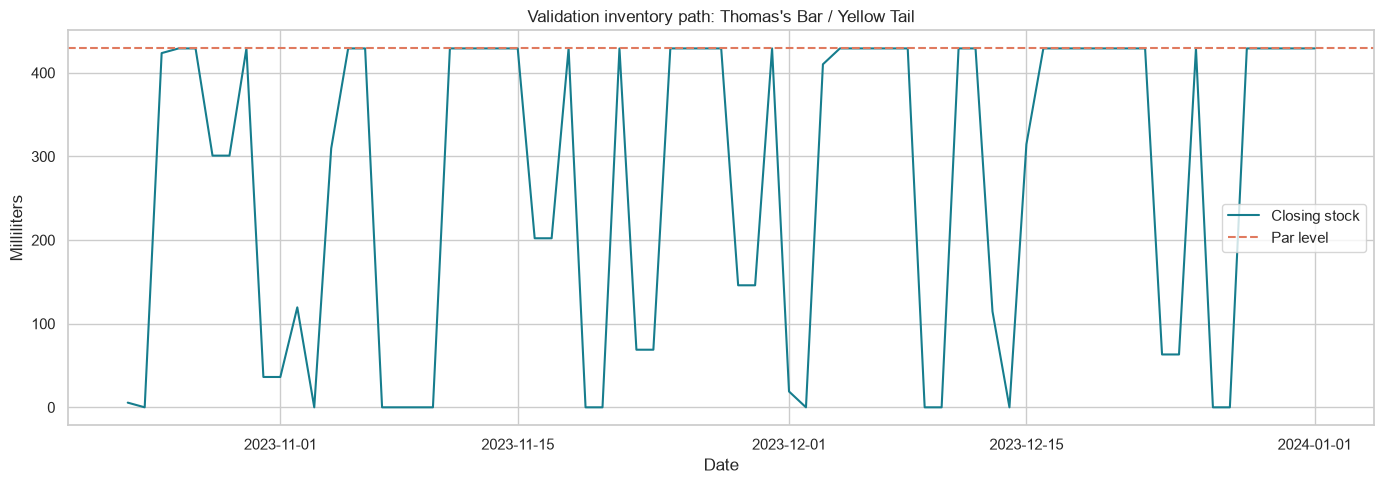

Report written to: d:\Nxtwave Projects\ML - Inventory Demand Forecasting and Par Level Recommendation System for Bars\report\business_report.md
PDF report written to: d:\Nxtwave Projects\ML - Inventory Demand Forecasting and Par Level Recommendation System for Bars\report\business_report.pdf
Selected policy: 9 stockout days, 1,446 ml lost volume


In [29]:
selected = test.groupby(['Bar Name', 'Brand Name'])['Consumed (ml)'].sum().idxmax()
selected_test = test[(test['Bar Name'] == selected[0]) & (test['Brand Name'] == selected[1])].copy()
selected_stat = series_stats[(series_stats['Bar Name'] == selected[0]) & (series_stats['Brand Name'] == selected[1])].iloc[0]
selected_sim = simulate_inventory(selected_test['Consumed (ml)'].to_numpy(), selected_stat['par_level_ml'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(selected_test['Date'], selected_sim['history'], label='Closing stock', color='#167d8d')
ax.axhline(selected_stat['par_level_ml'], color='#e07a5f', linestyle='--', label='Par level')
ax.set_title(f'Validation inventory path: {selected[0]} / {selected[1]}')
ax.set_ylabel('Milliliters')
ax.set_xlabel('Date')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'inventory_policy_example.png', dpi=160, bbox_inches='tight')
plt.show()

# Write a portable business report from the same notebook run.
report_text = f'''# Bar Inventory Forecasting and Par-Level Recommendation

## Executive summary
This notebook cleans the original transaction-level Excel dataset, analyzes consumption by alcohol category, forecasts demand with a seven-day moving average and Random Forest, evaluates the forecasts, and recommends inventory par levels for bar-brand items.

## Data and quality
- Source: `Consumption Dataset.xlsx`; transaction rows loaded: {quality['rows_loaded']:,}; completed daily rows: {len(daily_ts):,}.
- Scope: {daily_ts['Bar Name'].nunique()} bars, {daily_ts['Brand Name'].nunique()} brands, {len(pairs)} bar-brand series.
- Date range: {daily_ts['Date'].min().date()} to {daily_ts['Date'].max().date()}.
- Alcohol categories analyzed: {raw['Alcohol Type'].nunique()}.
- Invalid dates: {quality['invalid_dates']}; invalid numeric rows: {quality['invalid_numeric_values']}; duplicate rows: {quality['duplicate_rows']}.
- Maximum absolute conservation error: {raw['conservation_error_ml'].abs().max():.8f} ml.

## Forecast evidence
The chronological 80/20 validation compares a seven-day moving-average forecast, a seven-day seasonal-naive challenger, and a Random Forest using lags, rolling statistics, weekday, weekend, bar, and brand features. The moving-average MAE is {metrics.loc['7-day moving average', 'MAE_ml']:.1f} ml and WAPE is {metrics.loc['7-day moving average', 'WAPE']:.1%}. The Random Forest MAE is {metrics.loc['Random Forest', 'MAE_ml']:.1f} ml and WAPE is {metrics.loc['Random Forest', 'WAPE']:.1%}.

## Inventory recommendation
Par level = forecast daily demand x (lead time + review period) + safety stock. The policy uses {LEAD_TIME_DAYS} lead-time days, {REVIEW_PERIOD_DAYS} review-period day, and a 95% service target. The validation simulation produced {int(recommendations['stockout_days'].sum()):,} stockout days, {recommendations['lost_volume_ml'].sum():,.0f} ml lost volume, and {recommendations['average_inventory_ml'].sum():,.0f} ml summed average inventory across {len(recommendations)} series.

The highest-volume validation series was **{selected[0]} / {selected[1]}**, with {selected_sim['stockout_days']} stockout days and {selected_sim['lost_volume_ml']:,.0f} ml lost volume.

## Assumptions and next steps
Demand is measured in milliliters, unmet demand is treated as lost, lead time is constant, and observed consumption may be censored by historical stockouts. Add promotions, events, vendor lead-time variation, and a live inventory position before production deployment.
'''
(REPORT_DIR / 'business_report.md').write_text(report_text, encoding='utf-8')

with PdfPages(REPORT_DIR / 'business_report.pdf') as pdf:
    for figure_path in [
        FIGURE_DIR / 'category_consumption.png',
        FIGURE_DIR / 'eda_overview.png',
        FIGURE_DIR / 'forecast_model_comparison.png',
        FIGURE_DIR / 'inventory_policy_example.png',
    ]:
        image = plt.imread(figure_path)
        report_figure, report_ax = plt.subplots(figsize=(11, 7))
        report_ax.imshow(image)
        report_ax.axis('off')
        pdf.savefig(report_figure, bbox_inches='tight')
        plt.close(report_figure)

print(f'Report written to: {REPORT_DIR / "business_report.md"}')
print(f'PDF report written to: {REPORT_DIR / "business_report.pdf"}')
print(f'Selected policy: {selected_sim["stockout_days"]} stockout days, {selected_sim["lost_volume_ml"]:,.0f} ml lost volume')

## 6. Deliverables, file paths, and operational use

Running all cells creates:

- `Consumption Dataset.xlsx`: original transaction-level source data.
- `data/processed/daily_bar_consumption.csv`: cleaned complete daily series.
- `data/processed/category_consumption.csv`: alcohol-category consumption summary.
- `data/processed/abc_inventory_segmentation.csv`: A/B/C inventory priorities.
- `data/processed/forecast_metrics.csv`: moving-average, seasonal-naive, and Random Forest validation metrics.
- `data/processed/par_level_recommendations.csv`: item-level bar-brand reorder recommendations using the moving-average forecast.
- `models/forecasting_model.pkl`: serialized Random Forest model generated by the modular pipeline.
- `outputs/inventory_recommendations.csv`: deployment-ready recommendation table.
- `report/figures/`: category, EDA, model-comparison, and inventory-policy figures.
- `report/business_report.md` and `report/business_report.pdf`: generated business reports.
- `app.py`: optional Streamlit dashboard using the generated outputs.

The dashboard is launched from the project root with `python -m streamlit run app.py`. Use `outputs/inventory_recommendations.csv` as the manager review queue. Prioritize high lost-volume and stockout-risk series, verify supplier lead times, and monitor MAE, WAPE, stockouts, lost volume, holding inventory, and data quality after deployment.